# Hindcast Blocking Frequency — NOAA SFS beta1 reforecast

Companion to `hindcast_blocking_main.ipynb` (CESM2 S2S).  Same Davini et al. (2012)
blocking algorithm, same plotting layer — pointed at the NOAA SFS beta1
reforecast archive on S3.

**Source:**  `s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/{MM}/atm_daily.zarr`
- 7 published init months (daily product):  **Mar, Apr, May, Jun, Jul, Aug, Nov**
  (Sep folder exists but only ships `atm_monthly.zarr`; Jan/Feb/Oct/Dec not yet in beta1)
- 11 ensemble members (`m00`..`m10`)
- 35 initialization years (1991-01 → 2025-01), one init per month on the 1st
- 47 lead days → first 46 kept to match CESM cadence
- 1° global grid (181 × 360)
- Variable `HGT_500mb` → Z500 in metres, direct (no /g conversion)

**Workflow**
1.  (Once) Build Z500 cache from S3 → per-`(member, year)` NetCDFs matching the
    CESM cache layout.  Written by `build_z500_cache_from_sfs`.
2.  Compute blocking frequency per lead day, per member (same code path as CESM).
3.  Plot ensemble mean ± 1σ for selected lead days.

**Season coverage** (unique start dates per member across 35 y):
- **DJF** — 0 (no winter inits published)
- **MAM** — 105 (Mar, Apr, May)
- **JJA** — 105 (Jun, Jul, Aug)
- **SON** — 35  (Nov only)

## Imports

In [1]:
import importlib
import pandas as pd
import hindcast_blocking_utils as hb_utils
import hindcast_blocking_figs  as hb_figs

%load_ext autoreload
%autoreload 2

In [2]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [3]:
cluster = PBSCluster(
    account='P03010039',
    interface='ext',
    walltime='04:00:00',
    queue='main',
    cores=4,
    memory='32GB',
    processes=4,
    local_directory='/glade/derecho/scratch/rneale/dask-temp',
    log_directory='/glade/derecho/scratch/rneale/dask-temp',
)
cluster.scale(jobs=4)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc65.hpc.ucar.edu/8541/proxy/8787/status,
Dashboard: /node/crhtc65.hpc.ucar.edu/8541/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.173:38193,Workers: 0
Dashboard: /node/crhtc65.hpc.ucar.edu/8541/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


---
## TOP LEVEL OPTIONS

In [4]:
# ── Cache directory (SFS-specific to avoid mixing with CESM cache) ────────
CACHE_DIR       = hb_utils.SFS_CACHE_DIR
ERA5_PATH       = '/glade/derecho/scratch/rneale/ERA5/dmean/1deg/z500_era5_dmean_1x1.nc'
ERA5_VERIFY_DIR = hb_utils.ERA5_VERIFY_DIR

# ── Which SFS init months to ingest / analyse ─────────────────────────────
# All published daily months = ('03','04','05','06','07','08','11')
# Subset for a season, e.g. MAM = ('03','04','05')
SFS_MONTHS = hb_utils.SFS_INIT_MONTHS

# ── Year / member selection ───────────────────────────────────────────────
# None = all cached;  narrow for testing.
YEARS   = list(range(2015,2020))
MEMBERS = list(range(10))          # SFS reforecast has 11 members

# ── Season for blocking frequency ─────────────────────────────────────────
# 'DJF' is EMPTY in beta1 (no winter inits).  'MAM'/'JJA' are best-populated.
BLOCK_SEASON = 'MAM'

# ── Number of lead days (max 46 = SFS 47 minus one to match CESM) ─────────
N_LEADDAYS = 20

# ── Lead days to plot ─────────────────────────────────────────────────────
PLOT_LEAD_DAYS = [1, 2, 3, 4, 5, 10, 15, 20]

# ── Cache overwrite flags ─────────────────────────────────────────────────
OVERWRITE_Z500  = False
OVERWRITE_BLOCK = False

print(f'Season   : {BLOCK_SEASON}  |  n_leaddays : {N_LEADDAYS}')
print(f'Members  : {MEMBERS}')
print(f'Months   : {SFS_MONTHS}')
print(f'Cache    : {CACHE_DIR}')

Season   : MAM  |  n_leaddays : 20
Members  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Months   : ('03', '04', '05', '06', '07', '08', '11')
Cache    : /glade/derecho/scratch/rneale/NOAA_SFS


---
## 1. Build Z500 cache from NOAA SFS reforecast S3

Reads each `atm_daily.zarr` lazily over the network and writes one
`z500_hindcast_m{MM:02d}_{YYYY}.nc` per `(member, year)`.  Multiple
init months contribute to the same file; start dates are pooled and
sorted chronologically.  Existing files are skipped unless
`OVERWRITE_Z500=True`.

Requires `s3fs`, `zarr` in the environment.

In [5]:
hb_utils.z500_cache_status(cache_dir=CACHE_DIR)

Z500 cache: 385 file(s) in /glade/derecho/scratch/rneale/NOAA_SFS
  members: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]   years: [1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  m00:  [1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]  OK
  m01:  [1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]  OK
  m02:  [1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]  OK

In [6]:
hb_utils.build_z500_cache_from_sfs(
    cache_dir  = CACHE_DIR,
    months     = SFS_MONTHS,
    years      = YEARS,           # None → all 1991-2025
    members    = MEMBERS,
    n_leaddays = 46,              # always store the full 46-day window
    overwrite  = OVERWRITE_Z500,
)

build_z500_cache_from_sfs: months=['03', '04', '05', '06', '07', '08', '11']  years=[2015, 2016, 2017, 2018, 2019]  members=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  n_leaddays=46  →  /glade/derecho/scratch/rneale/NOAA_SFS
  opening s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/03/atm_daily.zarr
  opening s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/04/atm_daily.zarr
  opening s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/05/atm_daily.zarr
  opening s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/06/atm_daily.zarr
  opening s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/07/atm_daily.zarr
  opening s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/08/atm_daily.zarr
  opening s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/11/atm_daily.zarr

  → materializing 50 (member, year) file(s)
  [1/50] m00 2015: exists, skipping → z500_hindcast_m00_2015.nc
  [2/50] m00 2016: exists, skipping → z500_hindcast_m00_2016.nc
  [3/50] m00 2017: exists, skipping → z5

---
## 2. Compute blocking frequency

Every helper below is identical to the CESM notebook — the only
difference is `cache_dir=CACHE_DIR` pointing at the SFS cache.

### 2a. 1D blocking frequency — all lead days

In [7]:
block_freq_1d = hb_utils.block_freq_all_leaddays(
    n_leaddays       = N_LEADDAYS,
    block_diag       = '1D',
    cache_dir        = CACHE_DIR,
    years            = YEARS,
    members          = MEMBERS,
    save_block_cache = True,
    overwrite_block  = OVERWRITE_BLOCK,
    season           = BLOCK_SEASON,
)

  NOTE: restricting to 10 member(s) (m00–m09); excluded 1 member(s) outside requested range.
block_freq_all_leaddays: block_diag=1D  season=MAM  n_leaddays=20  years=[2015, 2016, 2017, 2018, 2019]  members=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

  lead day   1: 15 hindcasts  mean blocking 7.7%  (11.1s)
  lead day   2: 15 hindcasts  mean blocking 5.4%  (5.4s)
  lead day   3: 15 hindcasts  mean blocking 6.4%  (2.6s)
  lead day   4: 15 hindcasts  mean blocking 8.9%  (1.9s)
  lead day   5: 15 hindcasts  mean blocking 9.9%  (2.0s)
  lead day   6: 15 hindcasts  mean blocking 10.0%  (1.9s)
  lead day   7: 15 hindcasts  mean blocking 9.4%  (1.8s)
  lead day   8: 15 hindcasts  mean blocking 9.3%  (1.9s)
  lead day   9: 15 hindcasts  mean blocking 9.3%  (1.8s)
  lead day  10: 15 hindcasts  mean blocking 10.5%  (1.8s)
  lead day  11: 15 hindcasts  mean blocking 10.7%  (2.0s)
  lead day  12: 15 hindcasts  mean blocking 10.1%  (1.8s)
  lead day  13: 15 hindcasts  mean blocking 10.1%  (1.8s)
  lead day  14:

### 2b. 2D blocking frequency — all lead days

In [8]:
block_freq_2d = hb_utils.block_freq_all_leaddays(
    n_leaddays       = N_LEADDAYS,
    block_diag       = '2D',
    cache_dir        = CACHE_DIR,
    years            = YEARS,
    members          = MEMBERS,
    save_block_cache = True,
    overwrite_block  = OVERWRITE_BLOCK,
    season           = BLOCK_SEASON,
)

  NOTE: restricting to 10 member(s) (m00–m09); excluded 1 member(s) outside requested range.
block_freq_all_leaddays: block_diag=2D  season=MAM  n_leaddays=20  years=[2015, 2016, 2017, 2018, 2019]  members=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

  lead day   1: 15 hindcasts  mean blocking 4.3%  (2.4s)
  lead day   2: 15 hindcasts  mean blocking 3.7%  (1.7s)
  lead day   3: 15 hindcasts  mean blocking 3.7%  (1.7s)
  lead day   4: 15 hindcasts  mean blocking 4.3%  (1.7s)
  lead day   5: 15 hindcasts  mean blocking 4.6%  (1.6s)
  lead day   6: 15 hindcasts  mean blocking 4.9%  (1.7s)
  lead day   7: 15 hindcasts  mean blocking 4.8%  (1.7s)
  lead day   8: 15 hindcasts  mean blocking 4.6%  (1.7s)
  lead day   9: 15 hindcasts  mean blocking 4.3%  (1.7s)
  lead day  10: 15 hindcasts  mean blocking 4.7%  (1.6s)
  lead day  11: 15 hindcasts  mean blocking 4.7%  (1.7s)
  lead day  12: 15 hindcasts  mean blocking 4.6%  (1.5s)
  lead day  13: 15 hindcasts  mean blocking 4.7%  (1.7s)
  lead day  14: 15 hi

### 2b-diag. Day-4 → day-5 discontinuity check (2D blocking)

Three independent checks to narrow down the source of the abrupt background
2D blocking jump between lead 4 and lead 5:

1. **Cached NetCDF per-lead stats** — min/max/mean/std/NaN-fraction of Z500
   for one (member, year). A jump between lead 4 and 5 in min/max/mean says
   the anomaly is upstream of the algorithm (units, fill leak, data).
2. **Source zarr coordinates + chunks + encoding** — is the `lead` axis
   uniform? Where are chunk boundaries on the lead dim? Does the stored
   `_FillValue` match `_SFS_FILL`?
3. **Z500 maps at leads 3-6** for a single (member, start_date) — a
   structural change between two adjacent leads is diagnostic.

The domain-mean 2D frequency barely changes (4.3% → 4.6%), so any dramatic
spatial change is a redistribution — consistent with a data anomaly rather
than physical spinup.

In [ ]:
# ── Day-4 → day-5 2D blocking discontinuity diagnostic ─────────────────────
# Point at one cached (member, year) file; pick one start_date for the maps.
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import fsspec, warnings

DIAG_MEMBER  = 0
DIAG_YEAR    = 2015
DIAG_INIT_MM = '03'                # zarr to probe for chunks/encoding
LEADS_PROBE  = range(1, 11)        # per-lead stats
LEADS_MAP    = [3, 4, 5, 6]        # maps to eyeball
FILL         = hb_utils._SFS_FILL

# ── (1) Cached NetCDF: per-lead Z500 stats ────────────────────────────────
cache_file = CACHE_DIR / f'z500_hindcast_m{DIAG_MEMBER:02d}_{DIAG_YEAR}.nc'
print(f'(1) Per-lead Z500 stats from {cache_file.name}')
z_all = xr.open_dataset(cache_file)['Z500']
print(f'    start_date[0] = {str(z_all.start_date.values[0])[:10]}   '
      f'shape = {dict(z_all.sizes)}')
print(f'    {"lead":>5s}  {"min":>9s}  {"max":>9s}  {"mean":>9s}  '
      f'{"std":>8s}  {"nan_frac":>9s}  {"eq_FILL":>8s}')
for ld in LEADS_PROBE:
    z = z_all.sel(lead_day=ld)
    eq_fill = float(np.isclose(z.values, FILL, rtol=0, atol=1e15).mean())
    print(f'    {ld:5d}  {float(z.min()):9.1f}  {float(z.max()):9.1f}  '
          f'{float(z.mean()):9.2f}  {float(z.std()):8.2f}  '
          f'{float(z.isnull().mean()):9.4f}  {eq_fill:8.4f}')

# ── (2) Source zarr: lead coord, chunks, encoding ─────────────────────────
url = f's3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/{DIAG_INIT_MM}/atm_daily.zarr'
print(f'\n(2) Source zarr {url}')
mp = fsspec.get_mapper(url, anon=True)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=FutureWarning)
    ds_src = xr.decode_cf(xr.open_zarr(mp, consolidated=True),
                          decode_timedelta=False)
lead_vals = ds_src['lead'].values
print(f'    lead[:10]      = {lead_vals[:10]}')
print(f'    lead diff[:10] = {np.diff(lead_vals[:11])}')
print(f'    lead attrs     = {dict(ds_src["lead"].attrs)}')
hgt = ds_src['HGT_500mb']
print(f'    HGT_500mb.dims    = {hgt.dims}')
print(f'    HGT_500mb.chunks  = {hgt.chunks}')
enc = {k: hgt.encoding.get(k) for k in
       ('chunks', 'preferred_chunks', 'dtype', '_FillValue',
        'missing_value', 'add_offset', 'scale_factor')}
print(f'    HGT_500mb.encoding= {enc}')
print(f'    _SFS_FILL in code = {FILL:.10e}')

# Raw values at (member 0, init 0, lat=60, lon=0) for leads 1..8
raw = hgt.isel(member=0, init=0, lat=(np.abs(ds_src.lat.values - 60)).argmin(),
               lon=(np.abs(ds_src.lon.values - 0)).argmin()).isel(lead=slice(0, 8)).values
print(f'    raw HGT_500mb (mem0 init0 60N 0E) leads 0..7 = {np.round(raw, 2)}')

# ── (3) Z500 maps at leads 3-6 for the same (member, start_date) ──────────
print(f'\n(3) Z500 maps at leads {LEADS_MAP} for m{DIAG_MEMBER:02d} {DIAG_YEAR}, '
      f'start_date = {str(z_all.start_date.values[0])[:10]}')
fig, axs = plt.subplots(1, len(LEADS_MAP), figsize=(4.2 * len(LEADS_MAP), 3.8),
                        subplot_kw={'projection': ccrs.NorthPolarStereo()})
z_probe = z_all.isel(start_date=0)
vmin = float(z_probe.sel(lead_day=LEADS_MAP).min())
vmax = float(z_probe.sel(lead_day=LEADS_MAP).max())
for ax, ld in zip(axs, LEADS_MAP):
    ax.set_extent([-180, 180, 20, 90], crs=ccrs.PlateCarree())
    z = z_probe.sel(lead_day=ld)
    cs = ax.contourf(z.lon, z.lat, z.values,
                     levels=np.linspace(vmin, vmax, 21),
                     transform=ccrs.PlateCarree(), cmap='RdBu_r', extend='both')
    ax.coastlines(linewidth=0.5)
    ax.set_title(f'lead_day {ld}\n'
                 f'mean={float(z.mean()):.0f}  std={float(z.std()):.0f}',
                 fontsize=10)
fig.suptitle(f'Z500 (m) — m{DIAG_MEMBER:02d} {DIAG_YEAR} init {str(z_all.start_date.values[0])[:10]}',
             fontsize=11)
fig.colorbar(cs, ax=axs, orientation='horizontal', shrink=0.6, pad=0.05, label='Z500 (m)')
plt.show()

### 2c. GHGS (south gradient) — all lead days

In [9]:
block_ghgs = hb_utils.block_freq_all_leaddays(
    n_leaddays       = N_LEADDAYS,
    block_diag       = 'GHGS',
    cache_dir        = CACHE_DIR,
    years            = YEARS,
    members          = MEMBERS,
    save_block_cache = True,
    overwrite_block  = OVERWRITE_BLOCK,
    season           = BLOCK_SEASON,
)

  NOTE: restricting to 10 member(s) (m00–m09); excluded 1 member(s) outside requested range.
block_freq_all_leaddays: block_diag=GHGS  season=MAM  n_leaddays=20  years=[2015, 2016, 2017, 2018, 2019]  members=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

  lead day   1: 15 hindcasts  mean GHGS -14.66 m/deg  (1.8s)
  lead day   2: 15 hindcasts  mean GHGS -14.61 m/deg  (1.6s)
  lead day   3: 15 hindcasts  mean GHGS -14.36 m/deg  (1.8s)
  lead day   4: 15 hindcasts  mean GHGS -13.91 m/deg  (1.4s)
  lead day   5: 15 hindcasts  mean GHGS -13.68 m/deg  (1.6s)
  lead day   6: 15 hindcasts  mean GHGS -13.62 m/deg  (1.3s)
  lead day   7: 15 hindcasts  mean GHGS -13.85 m/deg  (1.2s)
  lead day   8: 15 hindcasts  mean GHGS -14.02 m/deg  (1.5s)
  lead day   9: 15 hindcasts  mean GHGS -13.97 m/deg  (1.5s)
  lead day  10: 15 hindcasts  mean GHGS -13.92 m/deg  (1.5s)
  lead day  11: 15 hindcasts  mean GHGS -13.92 m/deg  (1.7s)
  lead day  12: 15 hindcasts  mean GHGS -13.82 m/deg  (1.2s)
  lead day  13: 15 hindcasts

### 2d. GHGN (north gradient) — all lead days

In [10]:
block_ghgn = hb_utils.block_freq_all_leaddays(
    n_leaddays       = N_LEADDAYS,
    block_diag       = 'GHGN',
    cache_dir        = CACHE_DIR,
    years            = YEARS,
    members          = MEMBERS,
    save_block_cache = True,
    overwrite_block  = OVERWRITE_BLOCK,
    season           = BLOCK_SEASON,
)

  NOTE: restricting to 10 member(s) (m00–m09); excluded 1 member(s) outside requested range.
block_freq_all_leaddays: block_diag=GHGN  season=MAM  n_leaddays=20  years=[2015, 2016, 2017, 2018, 2019]  members=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

  lead day   1: 15 hindcasts  mean GHGN -7.03 m/deg  (1.6s)
  lead day   2: 15 hindcasts  mean GHGN -5.84 m/deg  (1.4s)
  lead day   3: 15 hindcasts  mean GHGN -5.59 m/deg  (1.2s)
  lead day   4: 15 hindcasts  mean GHGN -5.86 m/deg  (1.3s)
  lead day   5: 15 hindcasts  mean GHGN -6.30 m/deg  (1.3s)
  lead day   6: 15 hindcasts  mean GHGN -6.51 m/deg  (1.8s)
  lead day   7: 15 hindcasts  mean GHGN -6.78 m/deg  (1.3s)
  lead day   8: 15 hindcasts  mean GHGN -7.04 m/deg  (1.3s)
  lead day   9: 15 hindcasts  mean GHGN -7.16 m/deg  (1.3s)
  lead day  10: 15 hindcasts  mean GHGN -6.99 m/deg  (1.3s)
  lead day  11: 15 hindcasts  mean GHGN -6.79 m/deg  (1.4s)
  lead day  12: 15 hindcasts  mean GHGN -6.87 m/deg  (1.4s)
  lead day  13: 15 hindcasts  mean GHGN 

---
## 3. ERA5 reference lines

- `era5_clim_*` — full ERA5 climatology over the chosen season (no start-date filter). Grey dotted line in plots.
- `era5_verify_*` — same-season days from the SFS analysis years only. Black dashed line — the observed truth to compare hindcast lead days against.

In [11]:
era5_clim_1d = hb_utils.era5_season_clim_1d(ERA5_PATH, season=BLOCK_SEASON)
era5_clim_2d = hb_utils.era5_season_clim_2d(ERA5_PATH, season=BLOCK_SEASON)

# Analysis-year list: use the years actually present in the block-freq dict.
# (block_freq_all_leaddays doesn't return a year list; derive from cache instead.)
import re
cached_years = sorted({int(re.search(r'_(\d{4})\.nc', f.name).group(1))
                       for f in CACHE_DIR.glob('z500_hindcast_m*.nc')})
if YEARS is not None:
    cached_years = [y for y in cached_years if y in set(YEARS)]

era5_verify_1d = hb_utils.era5_verify_freq_1d(ERA5_VERIFY_DIR, cached_years, season=BLOCK_SEASON)
era5_verify_2d = hb_utils.era5_verify_freq_2d(ERA5_VERIFY_DIR, cached_years, season=BLOCK_SEASON)

era5_clim_ghgs   = hb_utils.era5_season_clim_gradient(ERA5_PATH, season=BLOCK_SEASON, diag='GHGS')
era5_clim_ghgn   = hb_utils.era5_season_clim_gradient(ERA5_PATH, season=BLOCK_SEASON, diag='GHGN')
era5_verify_ghgs = hb_utils.era5_verify_gradient(ERA5_VERIFY_DIR, cached_years, season=BLOCK_SEASON, diag='GHGS')
era5_verify_ghgn = hb_utils.era5_verify_gradient(ERA5_VERIFY_DIR, cached_years, season=BLOCK_SEASON, diag='GHGN')

era5_season_clim_1d: 2484 days  mean blocking 12.0%
era5_season_clim_2d: 2484 days  mean blocking 5.8%
era5_verify_freq_1d: 460 days  mean blocking 11.0%
era5_verify_freq_2d: 460 days  mean blocking 5.3%
era5_season_clim_gradient (GHGS): 2484 days  mean -12.74 m/deg
era5_season_clim_gradient (GHGN): 2484 days  mean -8.65 m/deg
era5_verify_gradient (GHGS): 460 days  mean -13.48 m/deg
era5_verify_gradient (GHGN): 460 days  mean -8.02 m/deg


---
## 4. Plot 1D blocking frequency — lines coloured by lead day

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_1d_hindcast_MAM_2015-2019.png
block_plot_1d_hindcast: done in 0.4s


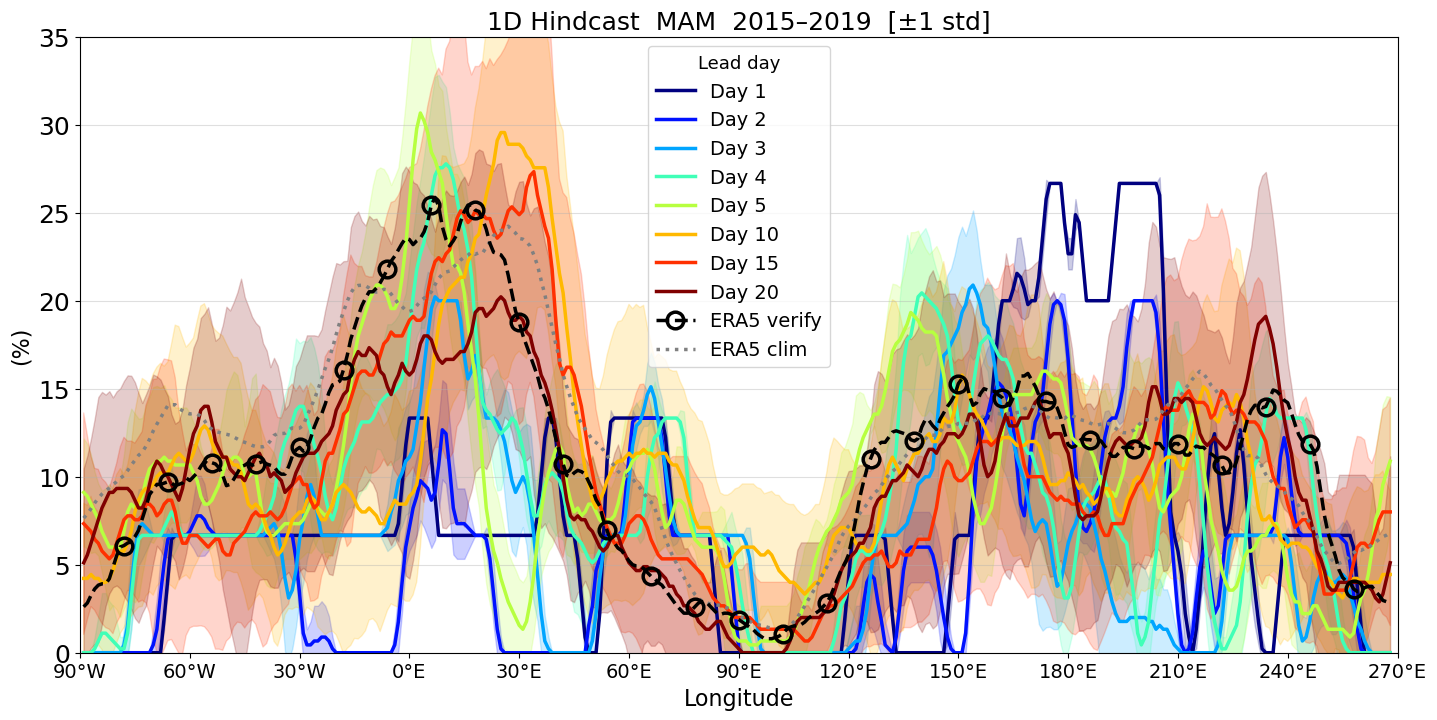

In [12]:
hb_figs.block_plot_1d_hindcast(
    block_freq_1d,
    lead_days      = PLOT_LEAD_DAYS,
    pshade         = '1',
    season         = BLOCK_SEASON,
    years          = cached_years,
    era5_verify_da = era5_verify_1d,
    era5_clim_da   = era5_clim_1d,
    fig_out        = True,
)

### 1D blocking — min/max spread

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_1d_hindcast_sfs_mmspread_MAM_2015-2019.png
block_plot_1d_hindcast: done in 0.3s


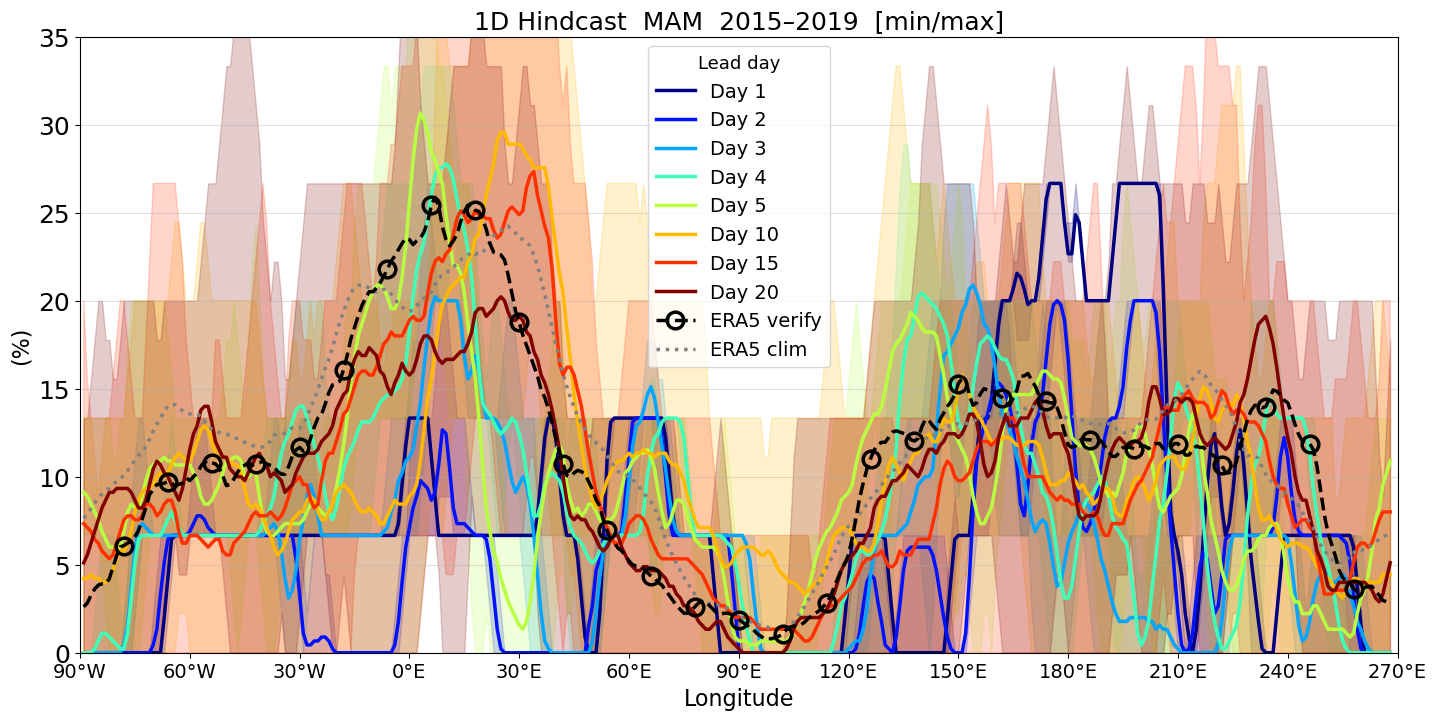

In [13]:
hb_figs.block_plot_1d_hindcast(
    block_freq_1d,
    lead_days      = PLOT_LEAD_DAYS,
    pshade         = 'mm',
    season         = BLOCK_SEASON,
    years          = cached_years,
    era5_verify_da = era5_verify_1d,
    era5_clim_da   = era5_clim_1d,
    fig_out        = True,
    fig_name       = 'block_1d_hindcast_sfs_mmspread',
)

---
## 5. Plot 2D blocking frequency — polar-map panels by lead day

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_2d_hindcast_MAM_2015-2019.png


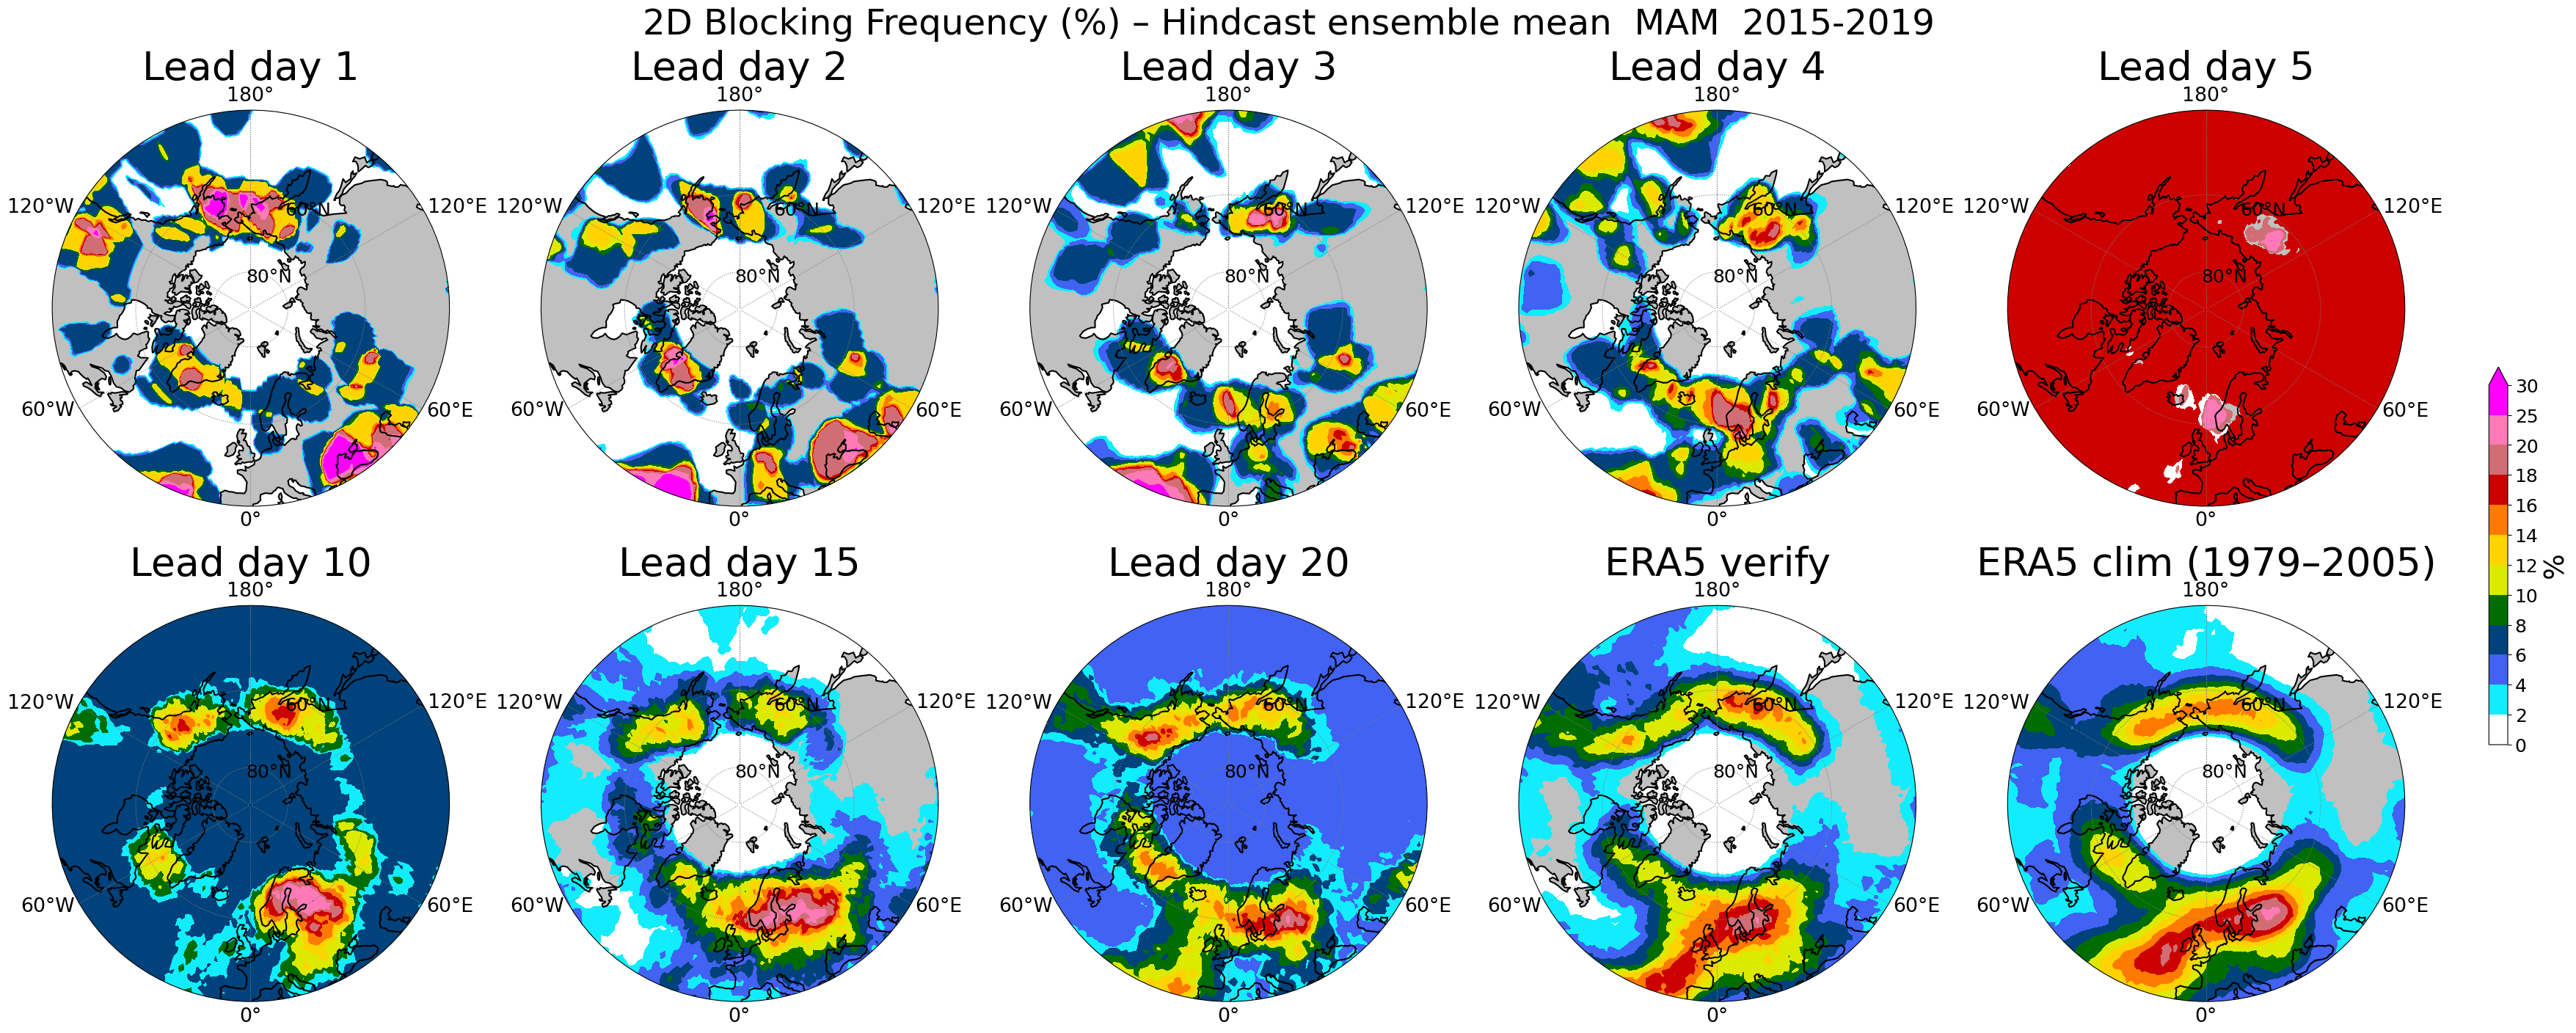

In [14]:
hb_figs.block_plot_2d_hindcast(
    block_freq_2d,
    lead_days      = PLOT_LEAD_DAYS,
    season         = BLOCK_SEASON,
    years          = cached_years,
    era5_verify_da = era5_verify_2d,
    era5_clim_da   = era5_clim_2d,
    max_cols       = 5,
    fig_out        = True,
)

### 5b. GHGS gradient — longitude lines by lead day

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_ghgs_hindcast_MAM_2015-2019.png
block_plot_1d_gradient (GHGS): done in 0.2s


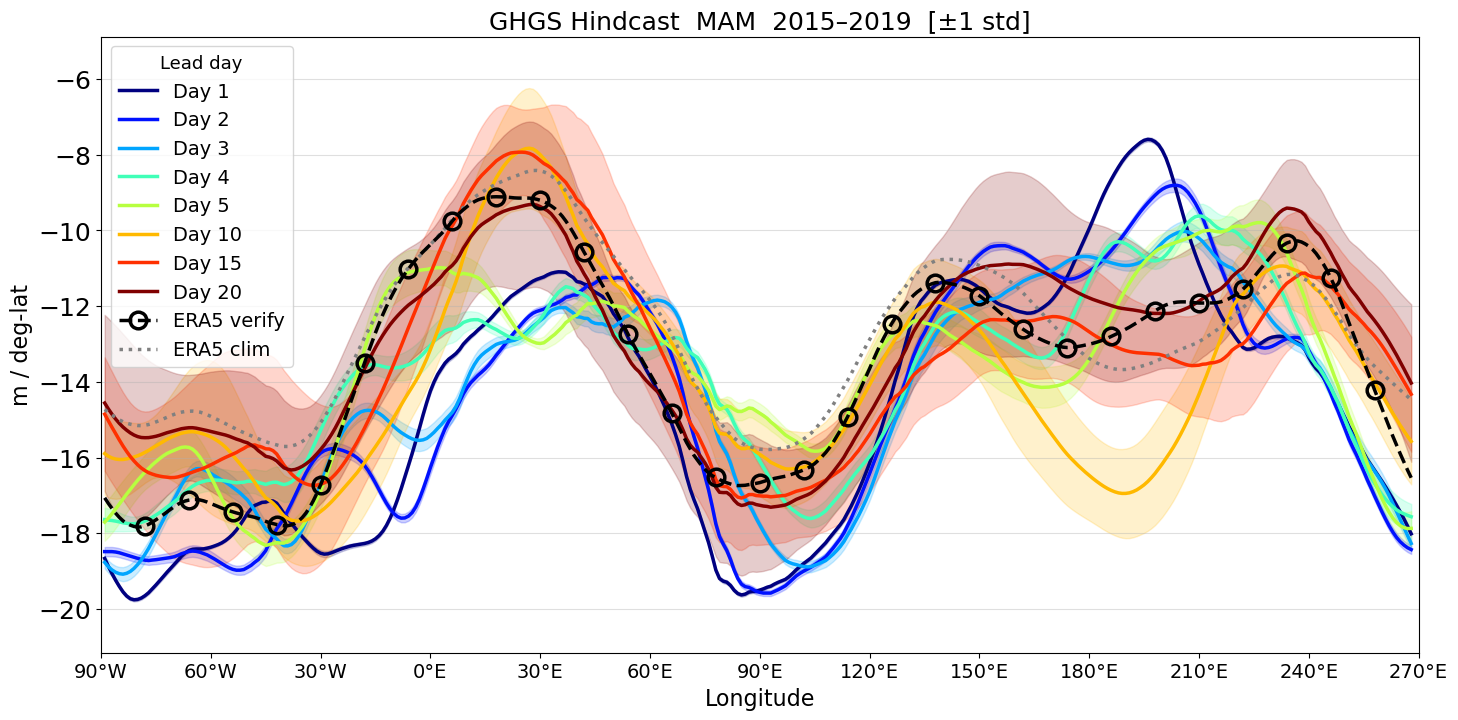

In [15]:
hb_figs.block_plot_1d_gradient(
    block_ghgs,
    diag_name      = 'GHGS',
    lead_days      = PLOT_LEAD_DAYS,
    pshade         = '1',
    season         = BLOCK_SEASON,
    years          = cached_years,
    era5_clim_da   = era5_clim_ghgs,
    era5_verify_da = era5_verify_ghgs,
    fig_out        = True,
)

### 5c. GHGN gradient — longitude lines by lead day

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_ghgn_hindcast_MAM_2015-2019.png
block_plot_1d_gradient (GHGN): done in 0.2s


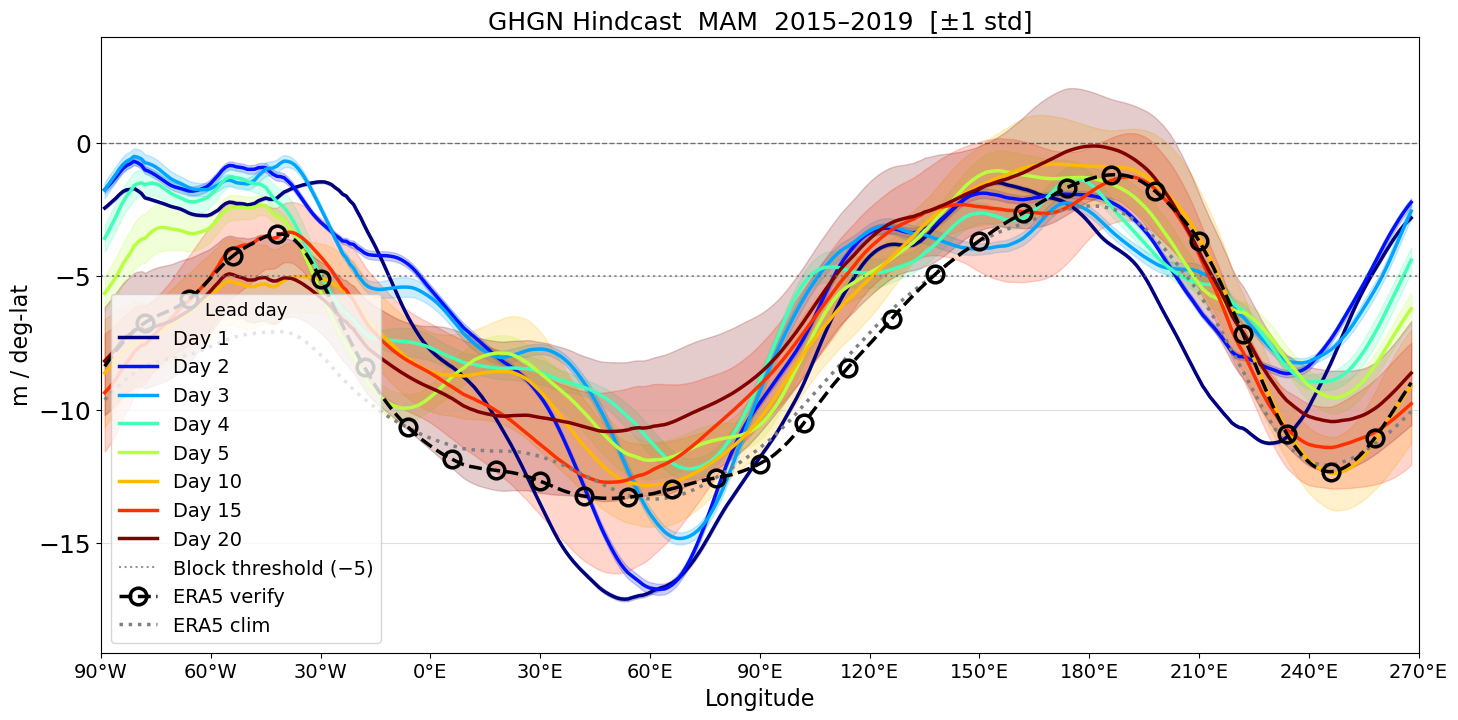

In [16]:
hb_figs.block_plot_1d_gradient(
    block_ghgn,
    diag_name      = 'GHGN',
    lead_days      = PLOT_LEAD_DAYS,
    pshade         = '1',
    season         = BLOCK_SEASON,
    years          = cached_years,
    era5_clim_da   = era5_clim_ghgn,
    era5_verify_da = era5_verify_ghgn,
    fig_out        = True,
)

---
## 6. Blocking frequency vs lead day (evolution plot)

  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_evolution_hindcast_MAM_2015-2019.png
block_plot_evolution: done in 0.1s
  Saved: /glade/u/home/rneale/python/python-figs/hindcast_blocking/block_evolution_hindcast_sfs_EUR_MAM_2015-2019.png
block_plot_evolution: done in 0.1s


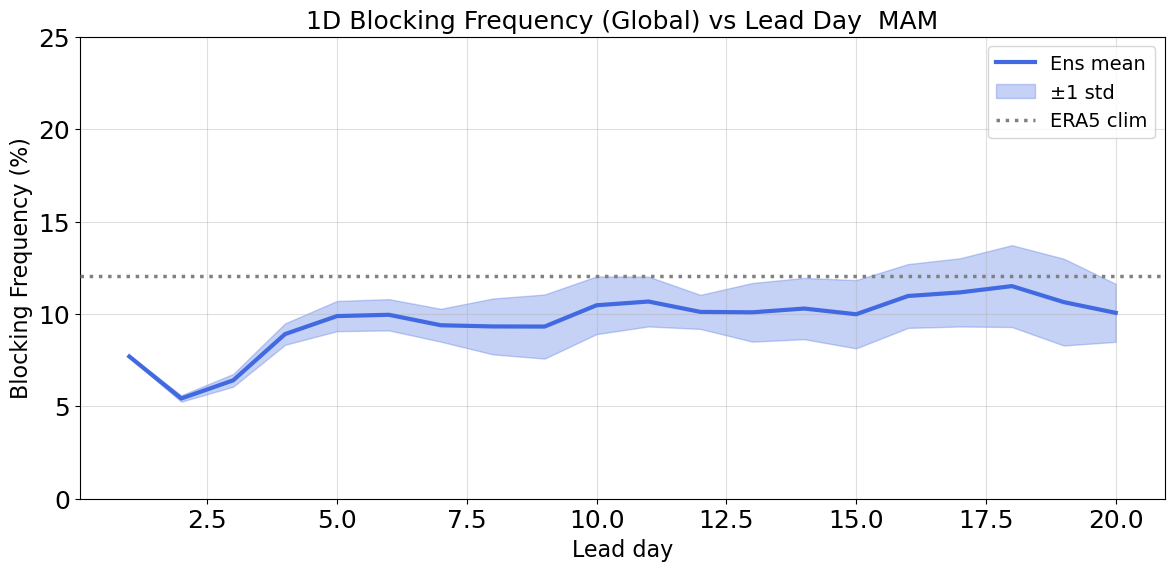

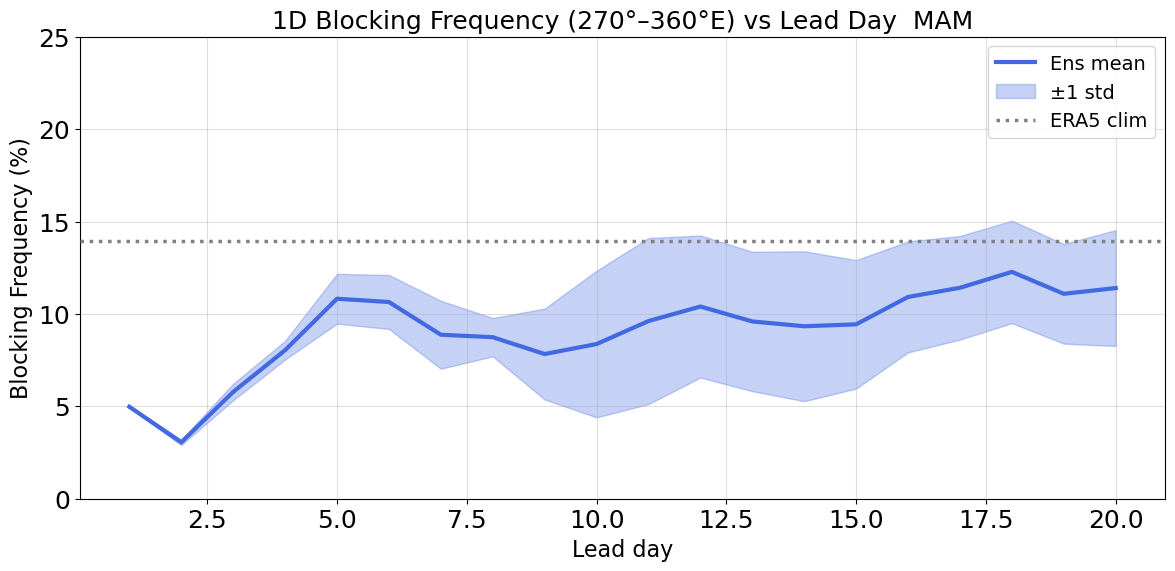

In [17]:
# Global average
hb_figs.block_plot_evolution(
    block_freq_1d,
    lon_range    = (0., 360.),
    season       = BLOCK_SEASON,
    years        = cached_years,
    era5_clim_da = era5_clim_1d,
    fig_out      = True,
)

# European sector
hb_figs.block_plot_evolution(
    block_freq_1d,
    lon_range    = (270., 360.),
    season       = BLOCK_SEASON,
    years        = cached_years,
    era5_clim_da = era5_clim_1d,
    fig_out      = True,
    fig_name     = 'block_evolution_hindcast_sfs_EUR',
)